In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
!pip install xgboost
from xgboost import XGBClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---- ----------------------------------- 12.3/101.7 MB 51.8 MB/s eta 0:00:02
   --------- ------------------------------ 23.6/101.7 MB 55.9 MB/s eta 0:00:02
   ---------- ----------------------------- 27.8/101.7 MB 41.4 MB/s eta 0:00:02
   ------------- -------------------------- 35.4/101.7 MB 40.0 MB/s eta 0:00:02
   --------------- ------------------------ 39.8/101.7 MB 36.6 MB/s eta 0:00:02
   ----------------- ---------------------- 44.3/101.7 MB 34.0 MB/s eta 0:00:02
   ------------------- -------------------- 49.0/101.7 MB 32.2 MB/s eta 0:00:02
   --------------------- ------------------ 53.5/101.7 MB 30.9 MB/s eta 0:00:02
   ---------------------- ----------------- 57.9/101.7 MB 30.0 MB/s eta 0:00:02
   ------------------------ --------------- 62.9/101.7 MB 29.2 MB/s eta 0:00:02
   -------------------------- ------------- 66.8/101.7 MB 

In [2]:
credit_card_df = pd.read_csv("C:/Users/ABHI ANTONY/Downloads/creditcard.csv/creditcard.csv")
credit_card_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
credit_card_df['Class'].unique()


array([0, 1])

In [4]:
credit_card_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
credit_card_df.shape


(284807, 31)

In [6]:
credit_card_df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
credit_card_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
legit = credit_card_df[credit_card_df.Class==0]
Fraud = credit_card_df[credit_card_df[ 'Class'] == 1]

In [9]:
legit.value_counts()

Time      V1         V2         V3         V4         V5         V6         V7         V8         V9         V10        V11        V12        V13        V14        V15        V16        V17        V18        V19        V20        V21        V22        V23        V24        V25        V26        V27        V28        Amount  Class
163152.0  -1.196037   1.585949   2.883976   3.378471   1.511706   3.717077   0.585362  -0.156001   0.122648   4.217934   1.385525  -0.709405  -0.256168  -1.564352   1.693218  -0.785210  -0.228008  -0.412833   0.234834   1.375790  -0.370294   0.524395  -0.355170  -0.869790  -0.133198   0.327804  -0.035702  -0.858197  7.56    0        18
          -1.203617   1.574009   2.889277   3.381404   1.538663   3.698747   0.560211  -0.150911   0.124136   4.220998   1.384569  -0.706897  -0.256274  -1.562583   1.692915  -0.787338  -0.226776  -0.412354   0.234322   1.385597  -0.366727   0.522223  -0.357329  -0.870174  -0.134166   0.327019  -0.042648  -0.855262  1.51    0   

In [10]:
legit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
Fraud.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1


In [12]:
Fraud.shape

(492, 31)

In [13]:
legit.shape

(284315, 31)

In [14]:
legit_sample = legit.sample(n=492)
credit_card_df = pd.concat([legit_sample,Fraud],axis=0)

In [15]:
credit_card_df['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

In [16]:
credit_card_df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,93435.215447,0.120330,0.005927,0.023082,-0.016333,-0.010976,-0.019867,0.106260,-0.035332,-0.007760,...,-0.027174,-0.001652,0.024655,-0.039254,0.023082,-0.006094,-0.012880,-0.017496,0.011239,81.375711
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [17]:
X = credit_card_df.drop('Class', axis=1)
Y = credit_card_df[ 'Class']

In [18]:
X.shape

(984, 30)

In [19]:
Y.shape

(984,)

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split (X, Y, test_size=0.2, stratify=Y, random_state = 2)

In [21]:
model = LogisticRegression()
model.fit(X_train,Y_train)
ypred = model.predict(X_test)

C:\Users\ABHI ANTONY\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
accuracy_score(ypred,Y_test)

0.9543147208121827

In [23]:
# Creating Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=2)

In [24]:
# Training the model
rf_model.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
# Making predictions
rf_ypred = rf_model.predict(X_test)

In [26]:
# Evaluating model accuracy
rf_accuracy = accuracy_score(rf_ypred, Y_test)
rf_accuracy

0.9390862944162437

In [27]:
# Creating XGBoost model
xgb_model = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=2)

In [28]:
# Training the model
xgb_model.fit(X_train, Y_train)

C:\Users\ABHI ANTONY\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:15:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [29]:
# Making predictions
xgb_ypred = xgb_model.predict(X_test)

In [30]:
# Evaluating model accuracy
xgb_accuracy = accuracy_score(xgb_ypred, Y_test)
xgb_accuracy

0.9441624365482234

In [31]:
# Precision for Logistic Regression
logistic_precision = precision_score(Y_test, ypred)

# Precision for Random Forest
rf_precision = precision_score(Y_test, rf_ypred)

# Precision for XGBoost
xgb_precision = precision_score(Y_test, xgb_ypred)

# Display the results
print("Logistic Regression Precision:", logistic_precision)
print("Random Forest Precision:", rf_precision)
print("XGBoost Precision:", xgb_precision)

Logistic Regression Precision: 0.989010989010989
Random Forest Precision: 1.0
XGBoost Precision: 0.978021978021978


In [32]:
# Compute Recall for Each Model
logistic_recall = recall_score(Y_test, ypred)
rf_recall = recall_score(Y_test, rf_ypred)
xgb_recall = recall_score(Y_test, xgb_ypred)

In [33]:
# Display Recall Scores
print("🔹 Logistic Regression - Recall:", round(logistic_recall, 4))
print("🔹 Random Forest - Recall:", round(rf_recall, 4))
print("🔹 XGBoost - Recall:", round(xgb_recall, 4))


🔹 Logistic Regression - Recall: 0.9184
🔹 Random Forest - Recall: 0.8776
🔹 XGBoost - Recall: 0.9082


In [34]:
import time

start_time = time.time()
rf_model.fit(X_train, Y_train)
end_time = time.time()

print("⏳ Training Time:", round(end_time - start_time, 2), "seconds")

⏳ Training Time: 0.41 seconds


In [35]:
print("Class Distribution in Training Data:")
print(Y_train.value_counts())  # Should be nearly equal for fraud (1) & legit (0)

Class Distribution in Training Data:
Class
1    394
0    393
Name: count, dtype: int64


In [36]:
# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=2)
rf_model.fit(X_train, Y_train) 


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


C:\Users\ABHI ANTONY\AppData\Local\Temp\ipykernel_19864\559634985.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


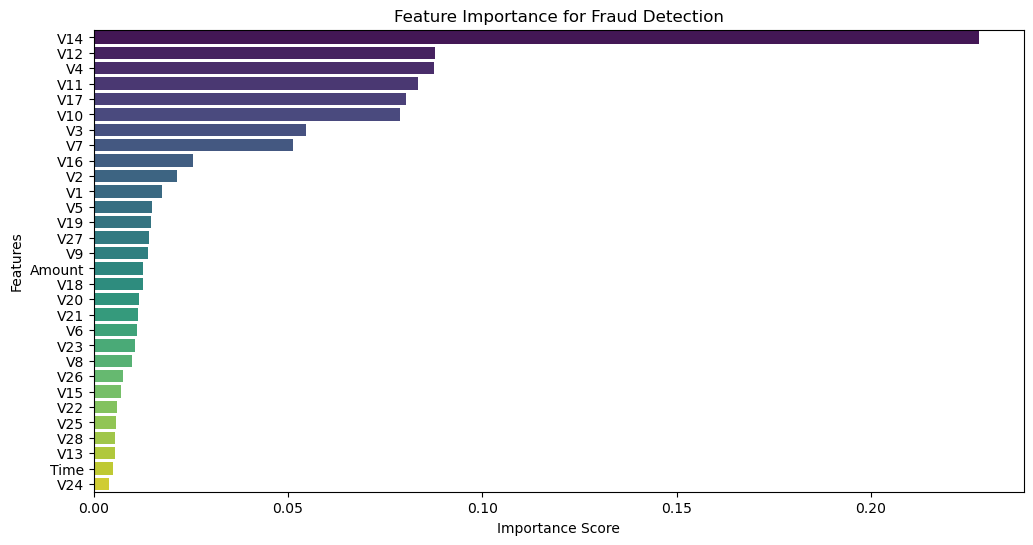

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance
feature_importance = rf_model.feature_importances_

# Create DataFrame for visualization
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12,6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title("Feature Importance for Fraud Detection")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [38]:
# Split fraud and non-fraud data
fraud_cases = credit_card_df[credit_card_df["Class"] == 1]
non_fraud_cases = credit_card_df[credit_card_df["Class"] == 0]

# Compare the average values of each feature (excluding 'Class')
fraud_mean = fraud_cases.drop(columns=["Class"]).mean()
non_fraud_mean = non_fraud_cases.drop(columns=["Class"]).mean()

# Create a DataFrame for comparison
feature_comparison = pd.DataFrame({
    'Feature': fraud_mean.index,  # Correct feature names
    'Fraud Mean': fraud_mean.values, 
    'Non-Fraud Mean': non_fraud_mean.values
})

# Calculate the absolute difference between fraud and non-fraud means
feature_comparison['Difference'] = abs(feature_comparison['Fraud Mean'] - feature_comparison['Non-Fraud Mean'])

# Sort by most significant differences
feature_comparison = feature_comparison.sort_values(by='Difference', ascending=False)

# Display the top differences
print(feature_comparison.head(10))

   Feature    Fraud Mean  Non-Fraud Mean    Difference
0     Time  80746.806911    93435.215447  12688.408537
29  Amount    122.211321       81.375711     40.835610
3       V3     -7.033281        0.023082      7.056363
14     V14     -6.971723        0.023464      6.995187
17     V17     -6.665836       -0.005199      6.660638
12     V12     -6.259393       -0.035680      6.223713
10     V10     -5.676883        0.009008      5.685891
7       V7     -5.568731        0.106260      5.674992
1       V1     -4.771948        0.120330      4.892279
4       V4      4.542029       -0.016333      4.558362


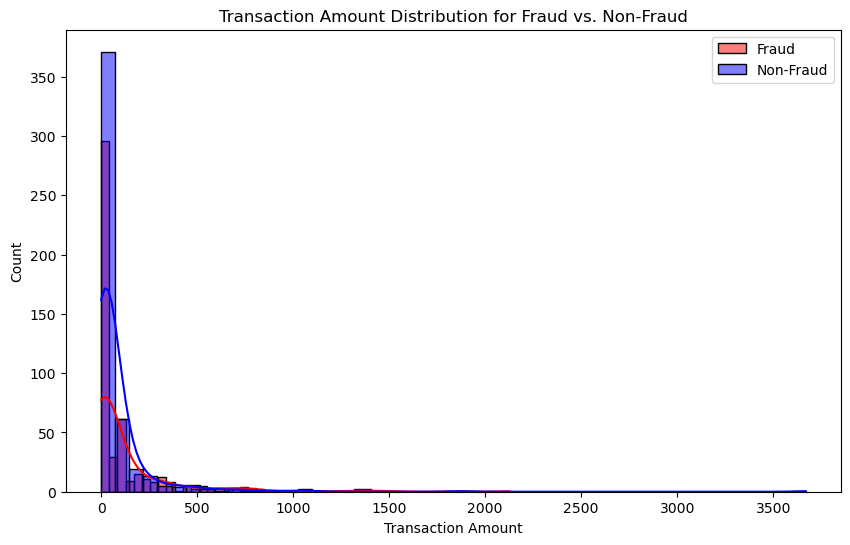

In [39]:
plt.figure(figsize=(10,6))
sns.histplot(fraud_cases['Amount'], bins=50, kde=True, color='red', label='Fraud')
sns.histplot(non_fraud_cases['Amount'], bins=50, kde=True, color='blue', label='Non-Fraud')
plt.title("Transaction Amount Distribution for Fraud vs. Non-Fraud")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")
plt.legend()
plt.show()

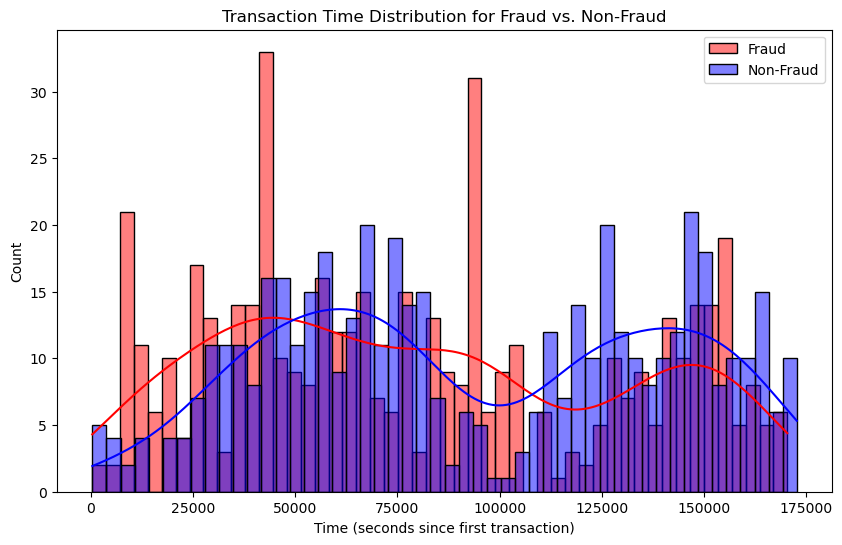

In [40]:
plt.figure(figsize=(10,6))
sns.histplot(fraud_cases['Time'], bins=50, kde=True, color='red', label='Fraud')
sns.histplot(non_fraud_cases['Time'], bins=50, kde=True, color='blue', label='Non-Fraud')
plt.title("Transaction Time Distribution for Fraud vs. Non-Fraud")
plt.xlabel("Time (seconds since first transaction)")
plt.ylabel("Count")
plt.legend()
plt.show()

In [41]:
# Select only the top important features (Based on feature importance results)
important_features = ["V14", "V17", "Amount", "V12", "V10", "V3", "V7", "V1", "V4"]
X = credit_card_df[important_features]
y = credit_card_df["Class"]

In [42]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2)

# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=2)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)


In [43]:
print("✅ Model Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("✅ Precision:", round(precision_score(y_test, y_pred), 4))
print("✅ Recall:", round(recall_score(y_test, y_pred), 4))

✅ Model Accuracy: 93.4 %
✅ Precision: 0.9885
✅ Recall: 0.8776


In [44]:
# Define fraud detection function
def detect_fraud(transaction):
    if (transaction["Amount"] > 2000) or (transaction["V14"] < -5) or (transaction["V17"] < -5):
        return 1  # Fraud
    return 0  # Legitimate

# Apply fraud detection rules to dataset
credit_card_df["Fraud_Predicted"] = credit_card_df.apply(detect_fraud, axis=1)

# Compare with actual fraud cases
fraud_cases = credit_card_df[credit_card_df["Class"] == 1]
fraud_detected = fraud_cases[fraud_cases["Fraud_Predicted"] == 1]

# Show performance
print("🔹 Total Fraud Cases:", len(fraud_cases))
print("🔹 Fraud Cases Detected by Rules:", len(fraud_detected))
print("🔹 Detection Rate:", round(len(fraud_detected) / len(fraud_cases) * 100, 2), "%")

🔹 Total Fraud Cases: 492
🔹 Fraud Cases Detected by Rules: 371
🔹 Detection Rate: 75.41 %


In [45]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from imblearn.over_sampling import SMOTE

credit_card_df = pd.read_csv("C:/Users/ABHI ANTONY/Downloads/creditcard.csv/creditcard.csv")
credit_card_df

# Separate features and target
X = credit_card_df.drop(columns=["Class"])
y = credit_card_df["Class"]

# Apply SMOTE for class balancing
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=2)

# Evaluation function
def evaluate(model, name):
    y_pred = model.predict(X_test)
    print(f"\n📊 {name} Evaluation:")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("F1 Score:", round(f1_score(y_test, y_pred), 4))
    print("ROC AUC:", round(roc_auc_score(y_test, y_pred), 4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 1. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
evaluate(rf, "Random Forest")

# 2. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
evaluate(lr, "Logistic Regression")

# 3. XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
evaluate(xgb, "XGBoost")



📊 Random Forest Evaluation:
Accuracy: 0.9998
Precision: 0.9997
Recall: 0.9999
F1 Score: 0.9998
ROC AUC: 0.9998
Confusion Matrix:
 [[56847    16]
 [    4 56859]]


C:\Users\ABHI ANTONY\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



📊 Logistic Regression Evaluation:
Accuracy: 0.9796
Precision: 0.9896
Recall: 0.9694
F1 Score: 0.9794
ROC AUC: 0.9796
Confusion Matrix:
 [[56281   582]
 [ 1740 55123]]


C:\Users\ABHI ANTONY\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:32:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 XGBoost Evaluation:
Accuracy: 0.9998
Precision: 0.9996
Recall: 1.0
F1 Score: 0.9998
ROC AUC: 0.9998
Confusion Matrix:
 [[56840    23]
 [    1 56862]]
